# 05 — Machine learning across six pairs

Combines the two previous extensions: the **ML pipeline of notebook 04** is run separately for each of the six pairs
of {soybean, corn, wheat, cotton}, and the per-pair strategies are combined with the **OU-based capital allocation of
notebook 03** (EW / MRB / MRR).

Per pair (first asset = dependent leg, so soybean–corn is the pair of notebook 04):
1. features from the pair's own spread plus the weather of the regions that grow *these two* crops
   (corn/soy: US Corn Belt + Brazil; wheat: Kansas, Oklahoma, North Dakota; cotton: Korla, Rajkot, Nagpur);
2. feature selection (MDI ∪ MDA, veto negative MDA) at a base configuration;
3. XGBoost grid and pipeline grid (Kalman δ, vertical barrier, barrier width) on the pair's dev set;
4. final model → holdout probabilities.

**Signal → position.** The notebook-04 holdout showed that the predicted probabilities are poorly calibrated, so
they are used only as a directional filter: long the spread if $p > 0.5 + \tau$, short if $p < 0.5 - \tau$, flat
otherwise, with $\tau = 0.15$. The Kalman hedge ratio is frozen at entry and returns are capital-normalised
(`backtest.spread_returns`), as for the classical strategies.

Tuning takes ~15 minutes; results are cached in `data/cache/ml_multi_pair/` (delete a file to re-tune that pair).

In [1]:
import sys, json, time
sys.path.insert(0, '..')
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from src.data import (load_full_dataset, load_etf_prices, weather_columns, SHORT_NAMES, CACHE_DIR,
                      save_figure, save_table)
from src.cv import temporal_split, WalkForwardPurgedCV, feat_importance_mda, feat_importance_mdi
from src.ml import (pair_frame, pair_labels, assemble_xy, select_features, make_xgb,
                    tune_xgb, tune_pipeline, band_positions)
from src.backtest import spread_returns, performance
from src.multipairs import compute_all_spreads, allocation_weights

np.random.seed(42)

ASSETS = ['soybean', 'corn', 'wheat', 'cotton']
PAIRS = list(combinations(ASSETS, 2))                    # (dependent, independent)
def pair_name(dep, ind): return f'{SHORT_NAMES[dep]}-{SHORT_NAMES[ind]}'

N_HOLDOUT = 375
TAU = 0.15
BASE = {'delta': 1e-6, 'num_days': 200, 'pt_sl': 2.5}    # configuration used for feature selection
SELECTION_MODEL = XGBClassifier(n_estimators=300, max_depth=2, learning_rate=0.1, min_child_weight=15,
                                eval_metric='logloss', random_state=42)

# OU allocation (fixed, as in notebook 03's defaults; affects weighting only)
OU_SPREAD_WINDOW, OU_WINDOW, REBAL_FREQ = 252, 63, 63

CACHE = CACHE_DIR / 'ml_multi_pair'
CACHE.mkdir(parents=True, exist_ok=True)
print('Pairs:', [pair_name(*p) for p in PAIRS])

Pairs: ['SOYB-CORN', 'SOYB-WEAT', 'SOYB-COTN', 'CORN-WEAT', 'CORN-COTN', 'WEAT-COTN']


## 1. Per-pair feature selection and tuning

In [2]:
def pair_data(dep, ind):
    df = load_full_dataset([dep, ind])
    return df, f'close_{dep}', f'close_{ind}', weather_columns(df, [dep, ind])


def tune_pair(dep, ind):
    df, dep_col, ind_col, weather = pair_data(dep, ind)
    d = pair_frame(df, dep_col, ind_col, weather, BASE['delta'])
    labels, weights = pair_labels(d, dep_col, ind_col, BASE['num_days'], BASE['pt_sl'])
    X, y, t1, w = assemble_xy(d, labels, weights)
    sp = temporal_split(X, y, t1, sample_weight=w, n_holdout=N_HOLDOUT, verbose=False)
    cv = WalkForwardPurgedCV(n_periods=3, t1=sp['t1_dev'])
    mda = feat_importance_mda(SELECTION_MODEL, sp['X_dev'], sp['y_dev'], sp['t1_dev'],
                              sample_weight=sp['w_dev'], cv=cv)
    mdi = feat_importance_mdi(sp['X_dev'], sp['y_dev'], sample_weight=sp['w_dev'])
    selected, _ = select_features(mdi, mda)

    xgb_table = tune_xgb(sp['X_dev'][selected], sp['y_dev'], sp['t1_dev'], sp['w_dev'])
    best_xgb = xgb_table.iloc[0].to_dict()
    pipe_table = tune_pipeline(df, dep_col, ind_col, weather, selected, best_xgb, n_holdout=N_HOLDOUT)
    return {'n_weather': len(weather), 'selected': selected,
            'best_xgb': best_xgb, 'best_pipe': pipe_table.iloc[0].to_dict()}


config = {}
for dep, ind in PAIRS:
    path = CACHE / f'{pair_name(dep, ind)}.json'
    if path.exists():
        config[(dep, ind)] = json.loads(path.read_text())
        continue
    t0 = time.time()
    config[(dep, ind)] = tune_pair(dep, ind)
    path.write_text(json.dumps(config[(dep, ind)], indent=2, default=float))
    print(f'{pair_name(dep, ind)} tuned in {time.time() - t0:.0f}s')

pd.DataFrame({pair_name(*p): {'weather offered': c['n_weather'], 'selected': len(c['selected']),
                              **{k: c['best_pipe'][k] for k in ['delta', 'num_days', 'pt_sl']},
                              'CV neg log-loss': c['best_pipe']['test_nll']}
              for p, c in config.items()}).T

SOYB-CORN tuned in 149s


SOYB-WEAT tuned in 150s


SOYB-COTN tuned in 164s


CORN-WEAT tuned in 121s


CORN-COTN tuned in 130s


WEAT-COTN tuned in 119s


,weather offered,selected,delta,num_days,pt_sl,CV neg log-loss
SOYB-CORN,90.0,32.0,0.000001,200.0,2.5,-0.670730
SOYB-WEAT,135.0,30.0,0.000010,200.0,2.5,-0.676797
SOYB-COTN,135.0,34.0,0.000100,150.0,2.5,-0.681720
CORN-WEAT,135.0,33.0,0.000010,150.0,2.5,-0.698892
CORN-COTN,135.0,34.0,0.000100,150.0,2.5,-0.678411
WEAT-COTN,90.0,29.0,0.000010,200.0,2.5,-0.681926


## 2. Final models, holdout positions and per-pair returns

In [3]:
pair_returns, pair_positions, pair_rows = {}, {}, {}
for dep, ind in PAIRS:
    c, name = config[(dep, ind)], pair_name(dep, ind)
    df, dep_col, ind_col, weather = pair_data(dep, ind)
    d = pair_frame(df, dep_col, ind_col, weather, c['best_pipe']['delta'])
    labels, weights = pair_labels(d, dep_col, ind_col, int(c['best_pipe']['num_days']), c['best_pipe']['pt_sl'])
    X, y, t1, w = assemble_xy(d, labels, weights, c['selected'])
    sp = temporal_split(X, y, t1, sample_weight=w, n_holdout=N_HOLDOUT, verbose=False)

    model = make_xgb(c['best_xgb']).fit(sp['X_dev'].values, sp['y_dev'].values, sample_weight=sp['w_dev'].values)
    prob = pd.Series(model.predict_proba(sp['X_holdout'].values)[:, 1], index=sp['X_holdout'].index)

    idx = prob.index
    positions = band_positions(prob, TAU)
    units = pd.DataFrame({dep_col: 1.0, ind_col: -d.loc[idx, 'kf_hedge_ratio']}, index=idx)
    ret = spread_returns(d.loc[idx, [dep_col, ind_col]], units, positions)

    pair_returns[name], pair_positions[name] = ret, positions
    pair_rows[name] = {'holdout start': idx[0].date(), 'holdout end': idx[-1].date(),
                       'accuracy': ((prob >= 0.5).astype(int) == sp['y_holdout']).mean(),
                       **performance(ret, positions)}

per_pair = pd.DataFrame(pair_rows).T
per_pair

,holdout start,holdout end,accuracy,Sharpe,Ann. return,Ann. vol,Total return,Max drawdown,In market,Trades
SOYB-CORN,2024-01-08,2025-07-08,0.597333,0.798894,0.049835,0.062379,0.073865,-0.064017,0.573333,24
SOYB-WEAT,2024-01-08,2025-07-08,0.538667,1.330008,0.089655,0.067409,0.138851,-0.050394,0.248,24
SOYB-COTN,2024-03-07,2025-09-15,0.584,-0.221842,-0.020374,0.091839,-0.035917,-0.085619,0.421333,14
CORN-WEAT,2024-03-20,2025-09-17,0.549333,NaN,0.0,0.0,0.0,0.0,0.0,0
CORN-COTN,2024-03-07,2025-09-15,0.464,NaN,0.0,0.0,0.0,0.0,0.0,0
WEAT-COTN,2023-12-21,2025-07-02,0.472,-0.422434,-0.027384,0.064824,-0.04291,-0.097802,0.189333,3


## 3. Combining the pairs with OU-based capital allocation

Weights are re-estimated every 63 days from OU fits to the last 63 days of each pair's 252-day rolling-OLS spread
(the scoring spread of notebook 03), and applied to the per-pair capital-normalised returns.

In [4]:
prices = load_etf_prices(ASSETS)
tickers = [(SHORT_NAMES[a], SHORT_NAMES[b]) for a, b in PAIRS]
spreads, _, _ = compute_all_spreads(prices, tickers, window=OU_SPREAD_WINDOW)
spread_df = pd.DataFrame({f'{a}-{b}': spreads[(a, b)] for a, b in tickers})

all_idx = pd.DatetimeIndex(sorted(set().union(*[r.index for r in pair_returns.values()])))
R = pd.DataFrame({name: r.reindex(all_idx).fillna(0.0) for name, r in pair_returns.items()})

portfolio = {m: (R * allocation_weights(spread_df, all_idx, m, REBAL_FREQ, OU_WINDOW)).sum(axis=1)
             for m in ['EW', 'MRB', 'MRR']}
ml_portfolio = pd.DataFrame({m: performance(r) for m, r in portfolio.items()}).T
save_table(pd.concat([per_pair.drop(columns=['holdout start', 'holdout end']),
                      ml_portfolio.rename(index=lambda m: f'portfolio {m}')]), '05_ml_multi_pair')
ml_portfolio.round(3)

,Sharpe,Ann. return,Ann. vol,Total return,Max drawdown,In market
EW,0.505,0.013,0.026,0.022,-0.026,0.765
MRB,0.680,0.029,0.043,0.050,-0.037,0.724
MRR,0.658,0.020,0.030,0.034,-0.029,0.765


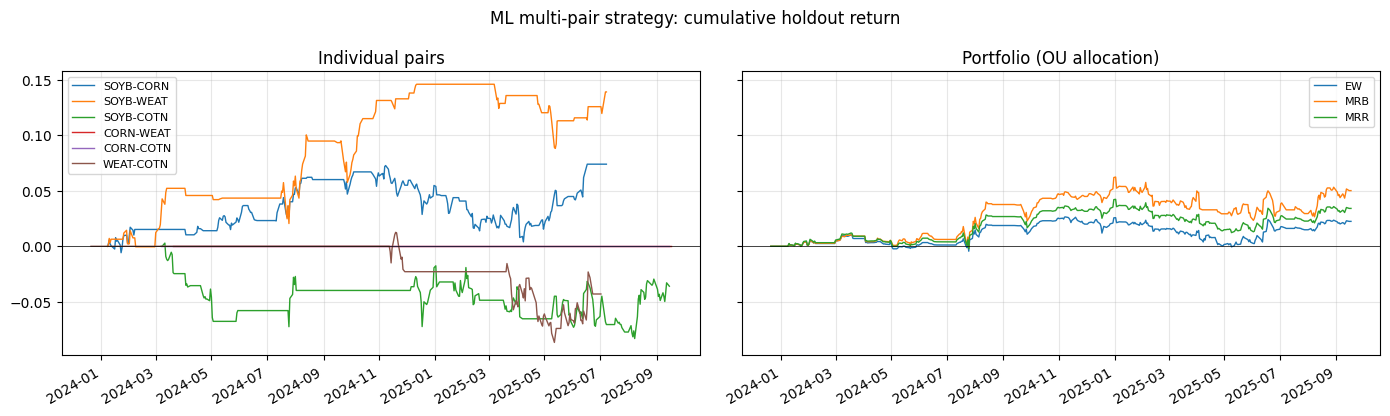

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2), sharey=True)
for name, r in pair_returns.items():
    ((1 + r).cumprod() - 1).plot(ax=axes[0], lw=1, label=name)
for m, r in portfolio.items():
    ((1 + r).cumprod() - 1).plot(ax=axes[1], lw=1, label=m)
axes[0].set_title('Individual pairs'); axes[1].set_title('Portfolio (OU allocation)')
for ax in axes:
    ax.axhline(0, color='k', lw=0.5); ax.grid(alpha=0.3); ax.legend(fontsize=8); ax.set_xlabel('')
fig.suptitle('ML multi-pair strategy: cumulative holdout return')
plt.tight_layout()
save_figure(fig, 'ml_multi_pair_returns')
plt.show()

**Take-aways.**
* The walk-forward CV signal is weakest for the pairs without soybean: for corn–wheat the CV log-loss is worse than a
  coin flip, and the corn–wheat and corn–cotton models never cross the confidence band on the holdout — they do not
  trade at all.
* The two soybean pairs with US-grown partners (corn, wheat) make money on the holdout, the pairs with cotton lose.
  The OU-weighted portfolio earns a Sharpe ratio of 0.5–0.7 over ~1.7 years — a standard error of about 0.8, and
  driven by two pairs.
* The result is sensitive to seemingly innocuous choices: before the clean-up (corn as the dependent leg of the
  corn–soybean pair, all pairs restricted to the common four-asset calendar) the same analysis gave portfolio Sharpe
  ratios between −0.2 and 0.